In [1]:
import pandas as pd
from pymatgen.core import Structure
import numpy as np

In [3]:
df = pd.read_json('./data/MP_dataset_cluster_0_1.json')
df

,nsites,nelements,formula_pretty,formula_anonymous,volume,density,material_id,energy_per_atom,formation_energy_per_atom,energy_above_hull,...,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber,frac s valence electrons,frac p valence electrons,frac d valence electrons,frac f valence electrons,compound possible,max ionic char,avg ionic char,label
0,14,3,Ba3OsN3,AB3C3,332.309469,6.438402,mp-1029640,-6.639529,-0.639654,0.00000,...,17.142857,194,0.325581,0.209302,0.139535,0.325581,False,0.685139,0.157102,0
1,6,2,As2Os,AB2,102.413553,11.027932,mp-2455,-27.770656,-0.303893,0.00000,...,12.444444,166,0.115385,0.115385,0.500000,0.269231,False,0.000100,0.000022,0
2,7,3,Ba2PbO4,AB2C4,125.836511,7.203060,mp-20098,-6.275103,-2.366581,0.00000,...,105.632653,12,0.250000,0.321429,0.178571,0.250000,True,0.803211,0.169289,0
3,5,3,Ca(MgBi)2,AB2C2,151.723980,5.545004,mp-29208,-3.125956,-0.536452,0.00000,...,92.320000,12,0.156250,0.093750,0.312500,0.437500,False,0.229026,0.039166,0
4,8,3,Tl3VS4,AB3C4,218.276540,6.027814,mp-5513,-4.949173,-0.855203,0.00000,...,66.375000,70,0.145455,0.172727,0.300000,0.381818,True,0.205784,0.051210,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,6,3,LiAgF4,ABC4,72.338285,4.379915,mp-861245,-7.908514,-1.868980,0.01043,...,94.222222,15,0.250000,0.500000,0.250000,0.000000,False,0.894601,0.177264,1
700,6,2,Ag2S,AB2,122.885288,6.697041,mp-556225,-17.033617,-0.118033,0.00000,...,68.888889,225,0.142857,0.142857,0.714286,0.000000,True,0.100238,0.022275,1
701,12,3,BaPPd,ABC,306.177431,5.959741,mp-1227860,-5.120960,-0.949516,0.00000,...,100.000000,2,0.235294,0.176471,0.588235,0.000000,False,0.348856,0.077053,1
702,14,3,K(SbSe2)2,AB2C4,429.799846,4.624308,mp-9797,-16.956796,-0.574348,0.00000,...,84.734694,14,0.136842,0.231579,0.631579,0.000000,False,0.526794,0.065749,1


## Export the structures in $C_{1}$ and $C_{2}$ for high-throughput calculations

In [4]:
import os

df_ = df.copy()
for i in range(df_.shape[0]):
    cwd_home = os.getcwd()
    path = './data/structures/'
    os.chdir(path)
    
    structure_id = df_.loc[i]['material_id']
    formula_id = df_.loc[i]['formula_pretty']
    poscar_name = "POSCAR-conventional_standard-" + formula_id + "-" + structure_id + ".vasp" 
    structure = Structure.from_dict(df_.loc[i]['structure_json'])
    structure.to(poscar_name, 'POSCAR')
    os.chdir(cwd_home)

## We employed the phonon-elasticity-thermal (PET) model proposed in our previous work within the HTC framework   

### https://pubs.acs.org/doi/10.1021/acs.jpca.2c06286

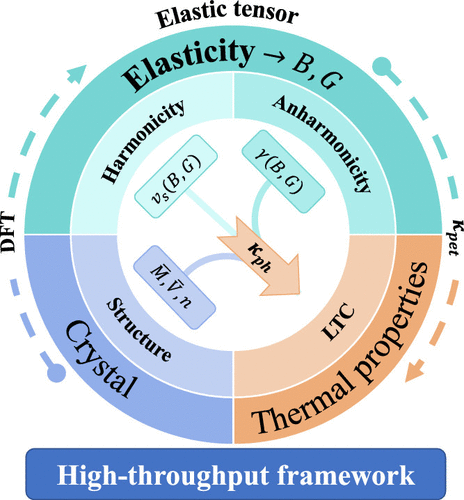